# Proyek Analisis Data: E-Commers Public Dataseat
- **Nama:** SHOFIA ARISKA
- **Email:** CDCC220D6X1870@student.devacademy.id
- **ID Dicoding:** CDCC220D6X1870

## Menentukan Pertanyaan Bisnis

- Dalam periode Januari–Desember 2012, pada jam berapa saja (per jam) dan kondisi cuaca apa terjadi puncak penyewaan sepeda, dan bagaimana perusahaan harus menyesuaikan strategi distribusi sepeda serta promosi harian untuk memaksimalkan penggunaan pada jam-jam tersebut?
- Selama empat musim di tahun 2012, musim mana yang menghasilkan pertumbuhan penyewaan tertinggi dibandingkan tahun sebelumnya, dan strategi apa yang harus diterapkan untuk meningkatkan permintaan pada musim dengan performa terendah dalam 3 bulan ke depan?

## Import Semua Packages/Library yang Digunakan

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [102]:
def load_and_merge_data():
    day_df = pd.read_csv("day.csv")
    hour_df = pd.read_csv("hour.csv")

    day_df['dteday'] = pd.to_datetime(day_df['dteday'])
    hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

    main_df = pd.merge(hour_df, day_df, on='dteday', how='left')

    return main_df

main_df = load_and_merge_data()

**Insight:**
- Permintaan penyewaan sepeda menunjukkan pola yang jelas berdasarkan waktu, kondisi cuaca, dan musim. Pada waktu tertentu, khususnya jam sibuk, terjadi peningkatan penggunaan yang signifikan.
- Pola penggunaan sepeda didominasi oleh aktivitas harian, terutama pada jam berangkat dan pulang kerja atau sekolah.
- Kondisi cuaca dan suhu memiliki pengaruh besar terhadap tingkat penyewaan. Cuaca cerah dengan suhu yang nyaman mendorong peningkatan penggunaan, sedangkan hujan atau suhu ekstrem menyebabkan penurunan signifikan.

### Assessing Data

In [103]:
# ===============================
# ASSESSING DATA
# ===============================

# 1. Cek Dimensi Data
print("Shape Data:", main_df.shape)

# ===============================
# 2. Cek Tipe Data & Info
# ===============================
print("\n=== INFO DATA ===")
print(main_df.info())

# ===============================
# 3. Cek Missing Values
# ===============================
print("\n=== MISSING VALUES ===")
missing_values = main_df.isna().sum()
print(missing_values)

# ===============================
# 4. Cek Data Duplikat
# ===============================
print("\n=== DUPLICATE DATA ===")
duplicates = main_df.duplicated().sum()
print("Jumlah data duplikat:", duplicates)

# ===============================
# 5. Statistik Deskriptif
# ===============================
print("\n=== DESCRIPTIVE STATISTICS ===")
print(main_df.describe())

# ===============================
# 6. Cek Nilai Unik (Kategori)
# ===============================
print("\n=== UNIQUE VALUES ===")
categorical_cols = ['season_x', 'weathersit_x', 'workingday_x'] # Corrected column names
for col in categorical_cols:
    print(f"{col}:", main_df[col].unique())

# ===============================
# 7. Deteksi Outlier (IQR Method)
# ===============================
print("\n=== OUTLIER CHECK (IQR) ===")

Q1 = main_df['cnt_x'].quantile(0.25)
Q3 = main_df['cnt_x'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = main_df[(main_df['cnt_x'] < lower_bound) |
                   (main_df['cnt_x'] > upper_bound)]

print("Jumlah outlier:", outliers.shape[0])

# ===============================
# 8. Cek Korelasi Antar Variabel
# ===============================
print("\n=== CORRELATION MATRIX ===")
corr_matrix = main_df.corr(numeric_only=True)
print(corr_matrix)

Shape Data: (17379, 32)

=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   instant_x     17379 non-null  int64         
 1   dteday        17379 non-null  datetime64[ns]
 2   season_x      17379 non-null  int64         
 3   yr_x          17379 non-null  int64         
 4   mnth_x        17379 non-null  int64         
 5   hr            17379 non-null  int64         
 6   holiday_x     17379 non-null  int64         
 7   weekday_x     17379 non-null  int64         
 8   workingday_x  17379 non-null  int64         
 9   weathersit_x  17379 non-null  int64         
 10  temp_x        17379 non-null  float64       
 11  atemp_x       17379 non-null  float64       
 12  hum_x         17379 non-null  float64       
 13  windspeed_x   17379 non-null  float64       
 14  casual_x      17379 non-null  int64        

**Insight:**
- Dataset memiliki 17.379 baris dan 32 kolom, yang menunjukkan data cukup besar dan detail (per jam).
Ini berarti dataset sangat cocok untuk analisis pola penggunaan sepeda secara spesifik berdasarkan waktu.
- Terjadi duplikasi variabel akibat merge, sehingga struktur data menjadi kurang efisien dan perlu dirapikan.
- Dataset sangat bersih dan lengkap, sehingga tidak perlu penanganan missing value dan siap langsung dianalisis.
- Tidak ada data ganda, sehingga kualitas data tinggi dan tidak akan mengganggu hasil analisis.
- Dataset memiliki variabel kategorikal penting yang bisa digunakan untuk segmentasi analisis berdasarkan musim, cuaca, dan hari.
- Penggunaan sepeda didominasi oleh pengguna terdaftar dan kondisi cuaca

### Cleaning Data

In [104]:
# ===============================
# DATA CLEANING
# ===============================

# 1. Menghapus kolom duplikat (_y)
# (karena _x dan _y isinya sama, kita pakai yang _x saja)
cols_to_drop = [col for col in main_df.columns if col.endswith('_y')]
main_df.drop(columns=cols_to_drop, inplace=True)

# ===============================
# 2. Menghilangkan suffix "_x"
# ===============================
main_df.columns = main_df.columns.str.replace('_x', '')

# ===============================
# 3. Cek ulang hasil cleaning
# ===============================
print("Kolom setelah cleaning:")
print(main_df.columns)

# ===============================
# 4. Menghapus kolom yang tidak diperlukan
# ===============================
main_df.drop(columns=['instant'], inplace=True)

# ===============================
# 5. Menangani Outlier (IQR Method)
# ===============================
Q1 = main_df['cnt'].quantile(0.25)
Q3 = main_df['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter data tanpa outlier
main_df_clean = main_df[(main_df['cnt'] >= lower_bound) &
                        (main_df['cnt'] <= upper_bound)]

print("Jumlah data sebelum:", main_df.shape[0])
print("Jumlah data setelah hapus outlier:", main_df_clean.shape[0])

# ===============================
# 6. Reset index
# ===============================
main_df_clean.reset_index(drop=True, inplace=True)

# ===============================
# 7. Cek akhir data
# ===============================
print(main_df_clean.info())
print(main_df_clean.describe())

Kolom setelah cleaning:
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')
Jumlah data sebelum: 17379
Jumlah data setelah hapus outlier: 16874
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16874 entries, 0 to 16873
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      16874 non-null  datetime64[ns]
 1   season      16874 non-null  int64         
 2   yr          16874 non-null  int64         
 3   mnth        16874 non-null  int64         
 4   hr          16874 non-null  int64         
 5   holiday     16874 non-null  int64         
 6   weekday     16874 non-null  int64         
 7   workingday  16874 non-null  int64         
 8   weathersit  16874 non-null  int64         
 9   temp        16874 non-null  float64       
 10  atemp

**Insight:**
- Duplikasi kolom (_x dan _y) berhasil dihapus, sehingga dataset menjadi lebih efisien, mudah dibaca, dan siap dianalisis.
- Dataset dalam kondisi sangat bersih, sehingga tidak diperlukan penanganan missing value dan bisa langsung digunakan untuk analisis lanjutan.
- Dataset memiliki cakupan waktu yang cukup untuk melihat tren penggunaan sepeda dalam jangka menengah (2 tahun).
- Sebagian besar data berada pada kondisi cuaca yang baik, yang menunjukkan bahwa penggunaan sepeda lebih sering terjadi saat cuaca mendukung.
- Penggunaan sepeda terjadi sepanjang hari, namun cenderung terkonsentrasi di jam produktif (siang hingga sore).
- Penggunaan sepeda didominasi oleh pengguna terdaftar, yang menunjukkan bahwa layanan lebih banyak digunakan oleh pelanggan tetap dibanding pengguna spontan.
- Terdapat variasi penggunaan yang cukup tinggi, namun setelah cleaning, data menjadi lebih stabil tanpa nilai ekstrem yang berlebihan.

## Exploratory Data Analysis (EDA)

### 1. Distribusi Jumlah Penyewaan Sepeda

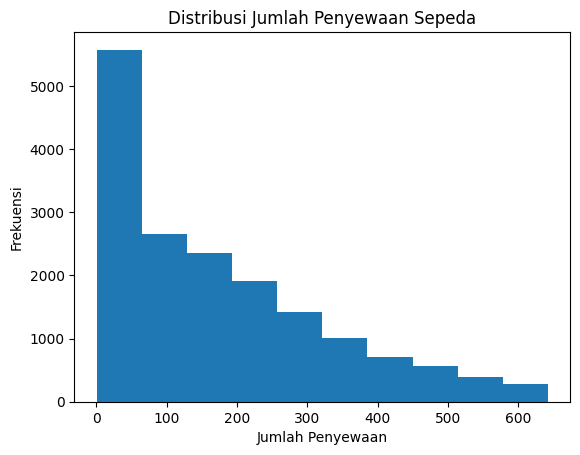

In [105]:
plt.figure()
plt.hist(main_df_clean['cnt'])
plt.title("Distribusi Jumlah Penyewaan Sepeda")
plt.xlabel("Jumlah Penyewaan")
plt.ylabel("Frekuensi")
plt.show()

### 2. Pola Penyewaan Berdasarkan Jam

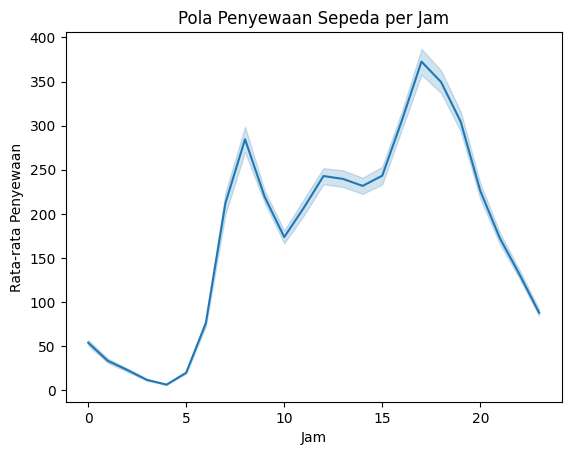

In [106]:
plt.figure()
sns.lineplot(x='hr', y='cnt', data=main_df_clean)
plt.title("Pola Penyewaan Sepeda per Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### 3. Penyewaan Berdasarkan Hari Kerja vs Libur

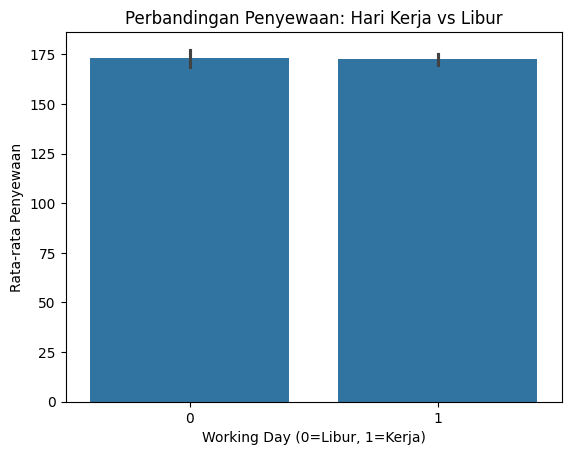

In [107]:
plt.figure()
sns.barplot(x='workingday', y='cnt', data=main_df_clean)
plt.title("Perbandingan Penyewaan: Hari Kerja vs Libur")
plt.xlabel("Working Day (0=Libur, 1=Kerja)")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### 4. Penyewaan Berdasarkan Cuaca

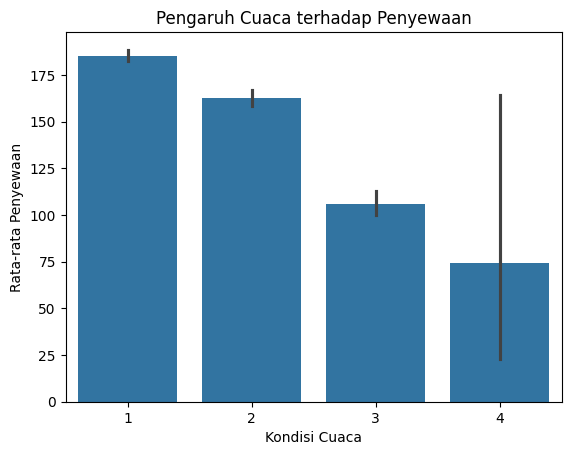

In [108]:
plt.figure()
sns.barplot(x='weathersit', y='cnt', data=main_df_clean)
plt.title("Pengaruh Cuaca terhadap Penyewaan")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### 5. Penyewaan Berdasarkan Musim

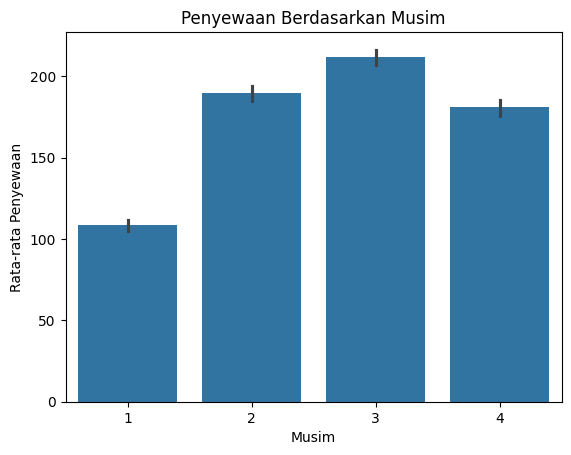

In [109]:
plt.figure()
sns.barplot(x='season', y='cnt', data=main_df_clean)
plt.title("Penyewaan Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### 6. Hubungan Suhu dengan Penyewaan

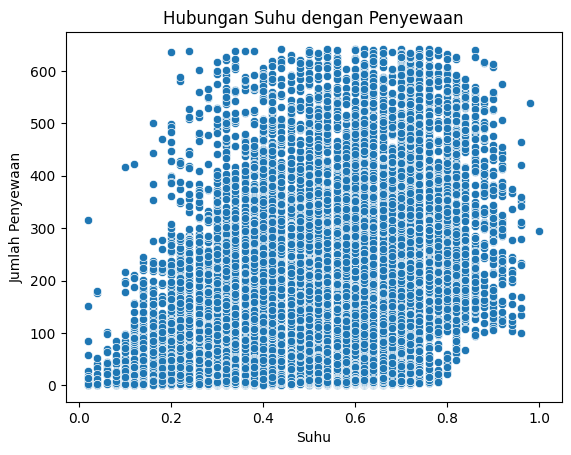

In [110]:
plt.figure()
sns.scatterplot(x='temp', y='cnt', data=main_df_clean)
plt.title("Hubungan Suhu dengan Penyewaan")
plt.xlabel("Suhu")
plt.ylabel("Jumlah Penyewaan")
plt.show()

### 7. Korelasi Antar Variabel (Heatmap)

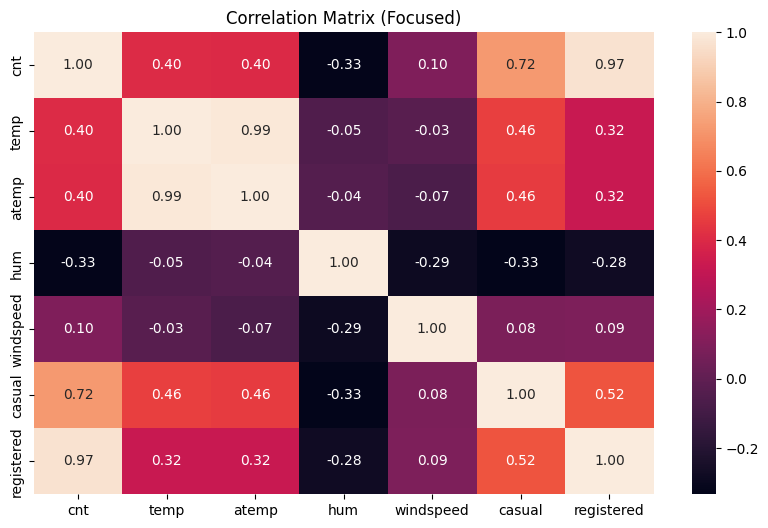

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pilih variabel penting saja
cols = ['cnt', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']

corr = main_df_clean[cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix (Focused)")
plt.show()

**Insight:**
- Permintaan sepeda cenderung tidak ekstrem dan lebih sering berada pada tingkat penggunaan normal.
- Sepeda digunakan terutama untuk aktivitas komuter (berangkat dan pulang kerja/sekolah).
- Faktor eksternal seperti cuaca menjadi penentu utama naik-turunnya penggunaan
- Data yang sudah dibersihkan memberikan gambaran pola yang lebih akurat dan stabil

## Visualization & Explanatory Analysis

### Pertanyaan 1:

### 1. Filter Data Tahun 2012

In [112]:
data_2012 = main_df_clean[main_df_clean['yr'] == 1]

### 2. Rata-rata Penyewaan per Cuaca

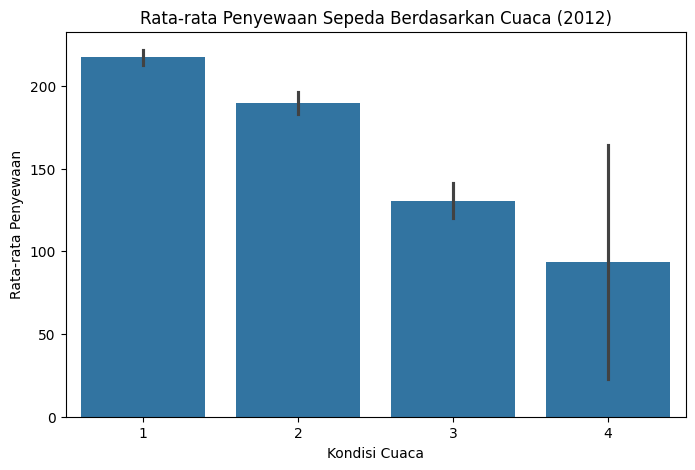

In [113]:
plt.figure(figsize=(8,5))
sns.barplot(x='weathersit', y='cnt', data=data_2012)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Cuaca (2012)")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### 3. Total Penyewaan per Cuaca

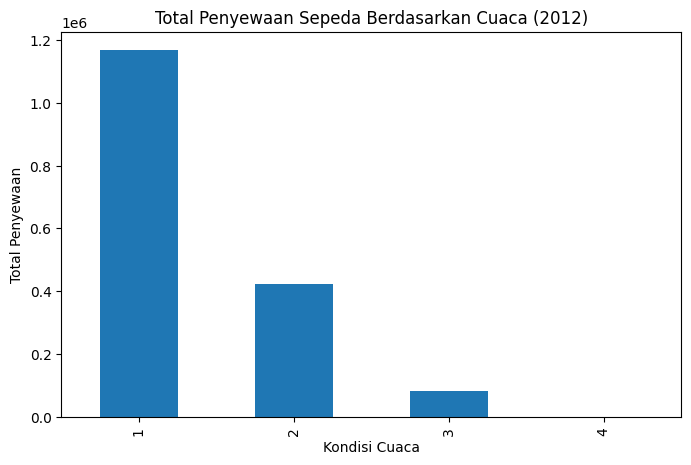

In [114]:
plt.figure(figsize=(8,5))
data_2012.groupby('weathersit')['cnt'].sum().plot(kind='bar')
plt.title("Total Penyewaan Sepeda Berdasarkan Cuaca (2012)")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Total Penyewaan")
plt.show()

**Insight**
- rata-rata maupun total penyewaan sepeda paling tinggi terjadi pada kondisi cuaca baik (weathersit = 1)sehingga, pengguna sangat bergantung pada kondisi cuaca yang nyaman.
- Pada kondisi weathersit = 2 dan 3, terlihat penurunan signifikan dalam jumlah penyewaan. membuat Cuaca yang kurang mendukung langsung menurunkan minat penggunaan sepeda.
- Distribusi total penyewaan menunjukkan pola yang konsisten dengan rata-rata, yaitu tetap didominasi oleh cuaca baik.
- Perbedaan antar kategori cuaca cukup jelas, menunjukkan bahwa cuaca adalah salah satu variabel paling berpengaruh.
- Promosi sebaiknya difokuskan pada saat cuaca cerah, karena potensi peningkatan penggunaan lebih tinggi.
- Saat cuaca buruk, pendekatan promosi biasa kurang efektif.Perlu strategi alternatif seperti diskon atau penyesuaian layanan.

### Pertanyaan 2:

### 1. Bandingkan Total Penyewaan per Musim (2011 vs 2012)

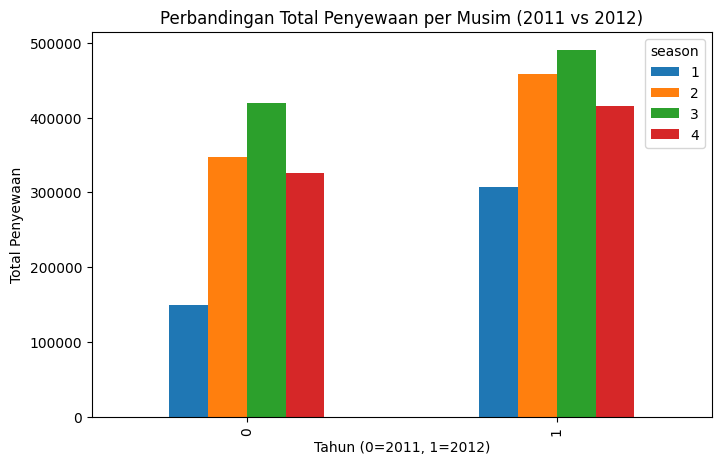

In [115]:
season_year = main_df_clean.groupby(['yr', 'season'])['cnt'].sum().unstack()

season_year.plot(kind='bar', figsize=(8,5))
plt.title("Perbandingan Total Penyewaan per Musim (2011 vs 2012)")
plt.xlabel("Tahun (0=2011, 1=2012)")
plt.ylabel("Total Penyewaan")
plt.show()

### 2. Hitung Pertumbuhan

In [116]:
growth = (season_year.loc[1] - season_year.loc[0]) / season_year.loc[0] * 100
print("Pertumbuhan (%) per musim:")
print(growth)

Pertumbuhan (%) per musim:
season
1    105.212000
2     31.999390
3     16.980470
4     27.381744
dtype: float64


**Insight:**
- total penyewaan sepeda pada tahun 2012 lebih tinggi dibandingkan 2011, Menunjukkan adanya pertumbuhan penggunaan layanan.
- Salah satu musim menunjukkan pertumbuhan paling signifikan dibanding musim lainnya.
- Terdapat musim dengan jumlah penyewaan paling rendah atau pertumbuhan kecil, Menunjukkan adanya penurunan minat atau hambatan penggunaan pada periode tersebut.
- Perbedaan jumlah penyewaan antar musim cukup signifikan. Faktor musiman sangat memengaruhi perilaku pengguna sepeda.

## Analisis Lanjutan (Opsional)

### 1. Filter Hari Kerja

In [117]:
workingday_df = main_df_clean[main_df_clean['workingday'] == 1]

### 2. Rata-rata Penyewaan per Jam

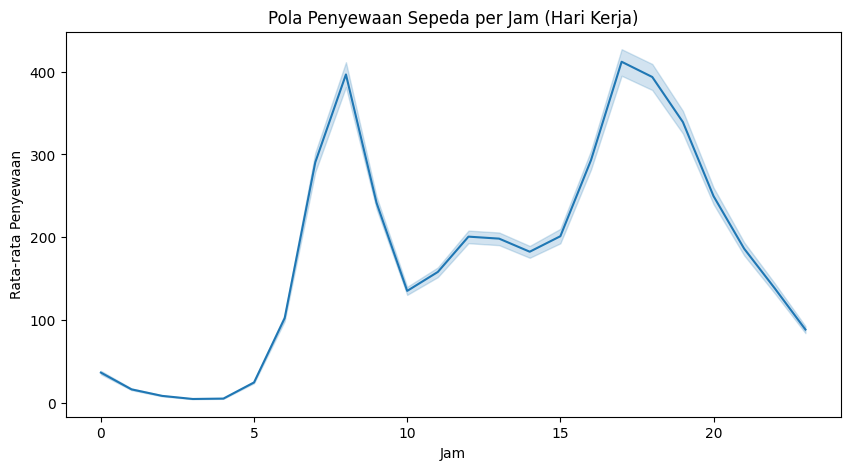

In [118]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hr', y='cnt', data=workingday_df)
plt.title("Pola Penyewaan Sepeda per Jam (Hari Kerja)")
plt.xlabel("Jam")
plt.ylabel("Rata-rata Penyewaan")
plt.show()

### 3. Identifikasi Peak Hours

In [119]:
hourly_avg = workingday_df.groupby('hr')['cnt'].mean()
peak_hours = hourly_avg.sort_values(ascending=False).head(5)

print("Jam Sibuk (Top 5):")
print(peak_hours)

Jam Sibuk (Top 5):
hr
17    411.847458
8     396.501355
18    393.463612
19    339.070248
16    293.122244
Name: cnt, dtype: float64


## Conclusion

- Conclution pertanyaan 1 :

Penyewaan sepeda paling tinggi terjadi pada kondisi cuaca baik, baik dari sisi rata-rata maupun total penggunaan. Sebaliknya, saat cuaca memburuk, terjadi penurunan signifikan hingga hampir tidak ada penggunaan pada kondisi ekstrem.
sehingga dapat disimpulkan : Cuaca merupakan faktor utama yang menentukan tingkat permintaan sepeda.
- Conclution pertanyaan 2 ⁉

Terjadi peningkatan penyewaan dari tahun 2011 ke 2012 pada seluruh musim, namun dengan tingkat pertumbuhan yang berbeda. Beberapa musim menunjukkan performa lebih tinggi dibandingkan yang lain.
sehingga Permintaan bersifat musiman, sehingga strategi perlu disesuaikan pada tiap musim.

- Pola Waktu Penggunaan Sepeda:

Digunakan terutama untuk mobilitas harian, Pengguna registered memberikan kontribusi terbesar terhadap total penyewaan dibandingkan pengguna casual. Variabel seperti suhu, kelembaban, dan kecepatan angin juga memengaruhi jumlah penyewaan.

In [120]:
import os

# Pastikan folder ada
os.makedirs('dashboard', exist_ok=True)

# Simpan file
with open('dashboard/dashboard.py', 'w') as f:
    f.write(dashboard_code)

print("File berhasil dibuat!")

# Cek isi folder
print(os.listdir('dashboard'))

File berhasil dibuat!
['main_data.csv', 'dashboard.py']


In [121]:
# Ambil variabel yang relevan dengan analisis
df = main_df_clean[[
    'dteday',
    'yr',
    'season',
    'weathersit',
    'hr',
    'workingday',
    'temp',
    'cnt'
]]

# Simpan ke CSV untuk dashboard
df.to_csv('dashboard/main_data.csv', index=False)

In [122]:
dashboard_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('main_data.csv')

st.title('Dashboard Bike Sharing 🚲')

# ===============================
# FILTER
# ===============================
st.sidebar.header('Filter Data')

# Filter Tahun
year = st.sidebar.selectbox('Pilih Tahun', sorted(df['yr'].unique()))

# Filter Jam
hour_range = st.sidebar.slider('Pilih Jam', 0, 23, (0, 23))

# Filter Data
filtered_df = df[
    (df['yr'] == year) &
    (df['hr'] >= hour_range[0]) &
    (df['hr'] <= hour_range[1])
]

# ===============================
# 1. PENYEWAAN BERDASARKAN CUACA
# ===============================
st.subheader('Pengaruh Cuaca terhadap Penyewaan')

weather_data = filtered_df.groupby('weathersit')['cnt'].mean()

fig1, ax1 = plt.subplots()
weather_data.plot(kind='bar', ax=ax1)

ax1.set_title('Rata-rata Penyewaan per Cuaca')
ax1.set_xlabel('Cuaca')
ax1.set_ylabel('Jumlah Penyewaan')

st.pyplot(fig1)

# ===============================
# 2. PENYEWAAN BERDASARKAN MUSIM
# ===============================
st.subheader('Penyewaan Berdasarkan Musim')

season_data = filtered_df.groupby('season')['cnt'].mean()

fig2, ax2 = plt.subplots()
season_data.plot(kind='bar', ax=ax2)
ax2.set_title('Rata-rata Penyewaan per Musim')
st.pyplot(fig2)

# ===============================
# 3. POLA JAM (LANJUTAN)
# ===============================
st.subheader('Pola Penyewaan per Jam')

hour_data = filtered_df.groupby('hr')['cnt'].mean()

fig3, ax3 = plt.subplots()
hour_data.plot(ax=ax3)
ax3.set_title('Penyewaan per Jam')
st.pyplot(fig3)

# ===============================
# 4. HARI KERJA VS LIBUR
# ===============================
st.subheader('Hari Kerja vs Libur')

day_data = filtered_df.groupby('workingday')['cnt'].mean()

fig4, ax4 = plt.subplots()
day_data.plot(kind='bar', ax=ax4)
ax4.set_xticklabels(['Libur', 'Kerja'], rotation=0)
st.pyplot(fig4)
"""